# Non-Curated 

**(Minimal QA - Just Process Everything)**

Minimal QA pipeline - the quick and dirty approach
- Valid mask: Only pixels where both bands > 0 are processed

What get's skipped:
- Cloud mask validation / refinement
- Atmospheric correction QA
- Co-registration checks
- Outlier removal
- Edge artifacts handling
- NBR calculation only in Vegetated area
- Bright surfaces removal

Sentinel-2 L2A bands are scaled surface reflectanc (x10000) store as integers, not raw DN


## Basic cloud mask using high-confidence clouds

In [1]:
import os
import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba
import matplotlib.cm as cm
from scipy.ndimage import binary_dilation, binary_fill_holes, binary_closing, binary_erosion, binary_opening, label
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from rasterio.features import rasterize
from rasterio import features
import warnings
import geopandas as gpd
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union
import logging

## 1. Load Sentinel-2 Bands

In [2]:
# ─── 1. Directorios ────────────────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, r'output\non_qa')
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PREFIRE_DIR = os.path.join(DATA_DIR, 'prefire')
DATA_POSTFIRE_DIR = os.path.join(DATA_DIR, 'postfire')
OUT_PREFIRE_DIR = os.path.join(OUTPUT_DIR, 'prefire')
OUT_POSTFIRE_DIR = os.path.join(OUTPUT_DIR, 'postfire')

AOI_PATH = os.path.join(DATA_DIR, 'aoi.geojson')
LANDUSE_PATH = os.path.join(DATA_DIR, 'landuse_aoi.geojson')
FIRE_PATH = os.path.join(DATA_DIR, 'true_perimeter.geojson')

# ─── 2. Rutas corregidas (ejemplo 2025-08-01 y 2025-08-23) ───

clip_pre = {
    'B8A': os.path.join(DATA_PREFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_PREFIRE_DIR, 'clip_swir2.tiff')
}

clip_post = {
    'B8A': os.path.join(DATA_POSTFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_POSTFIRE_DIR, 'clip_swir2.tiff')
}

NBR_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nbr_pre_no_qa.tif')
NBR_POST = os.path.join(OUT_POSTFIRE_DIR, 'nbr_post_no_qa.tif')

DNBR_PATH = os.path.join(OUTPUT_DIR, 'dnbr.tif')
SEVERITY_PATH = os.path.join(OUTPUT_DIR, 'severity_no_qa.tif')
POLYGON_PATH = os.path.join(OUTPUT_DIR, 'burn_polygons_no_qa.gpkg')

## 2. Calculate NBR

NBR is not a vegetation detector so it must be restricted to vegetated pixels. Otherwise bare ground mimics burn scars

In [3]:
def non_curated_nbr(
    b8a_path, b12_path,
    out_path=None
):
    """
    Calculate basic NBR (non-curated, no QA, no brightness filter).
    
    - Uses only B8A (NIR narrow) and B12 (SWIR2)
    - No QA masks
    - No brightness filter
    - Allows small negative reflectance values (common in Sentinel-2 L2A clips)
    - Focuses on excluding nodata and preventing bad division
    """
    print("\nCalculating NBR (non-curated / no QA, no brightness)...")

    # ─── Load bands ─────────────────────────────────────────────
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32")
        meta = src.meta.copy()
        nodata = src.nodata if src.nodata is not None else -9999.0
        print(f"Detected nodata: {nodata}")

    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32")

    # ─── Diagnostics ────────────────────────────────────────────
    print(f"B8A  min/mean/max: {b8a.min():.4f} / {b8a.mean():.4f} / {b8a.max():.4f}")
    print(f"B12  min/mean/max: {b12.min():.4f} / {b12.mean():.4f} / {b12.max():.4f}")
    print(f"B8A finite & != nodata fraction: {np.mean((b8a != nodata) & np.isfinite(b8a)):.1%}")
    print(f"B12 finite & != nodata fraction: {np.mean((b12 != nodata) & np.isfinite(b12)):.1%}")

    # ─── Validity & computation readiness ───────────────────────
    eps = 1e-10

    # Exclude nodata and non-finite values
    data_exists = (
        (b8a != nodata) & np.isfinite(b8a) &
        (b12 != nodata) & np.isfinite(b12)
    )

    # Require denominator not too negative/small (prevents extreme NBR artifacts)
    denom_ok = (b8a + b12) > -0.15   # tolerant threshold — adjust if needed

    compute_mask = data_exists & denom_ok

    # ─── Compute NBR ────────────────────────────────────────────
    nodata_out = -9999.0
    nbr = np.full_like(b8a, nodata_out, dtype="float32")
    nbr[compute_mask] = (b8a[compute_mask] - b12[compute_mask]) / \
                        (b8a[compute_mask] + b12[compute_mask] + eps)

    # Clip to physical range [-1, 1]
    nbr_valid = nbr[compute_mask]
    out_of_range = np.sum((nbr_valid < -1) | (nbr_valid > 1))
    if out_of_range > 0:
        print(f"⚠️ Clipped {out_of_range:,} NBR values outside [-1, 1]")
        nbr[compute_mask] = np.clip(nbr[compute_mask], -1.0, 1.0)

    # Report
    masked_count = np.sum(~compute_mask)
    print(f"Masked pixels: {masked_count:,} ({masked_count / nbr.size:.1%})")
    print(f"Valid computed pixels: {np.sum(compute_mask):,} ({np.mean(compute_mask):.1%})")

    # ─── Write output ───────────────────────────────────────────
    meta.update(
        driver="GTiff",
        count=1,
        dtype="float32",
        nodata=nodata_out,
        compress="lzw"
    )

    if out_path:
        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(nbr, 1)

    return nbr

In [4]:
nbr_pre = non_curated_nbr(
    clip_pre['B8A'],
    clip_pre['B12'],
    NBR_PRE
)

nbr_post = non_curated_nbr(
    clip_post['B8A'],
    clip_post['B12'],
    NBR_POST
)


Calculating NBR (non-curated / no QA, no brightness)...
Detected nodata: -9999.0
B8A  min/mean/max: -9999.0000 / 3216.8188 / 8965.0000
B12  min/mean/max: -9999.0000 / 1471.9269 / 7577.0000
B8A finite & != nodata fraction: 95.4%
B12 finite & != nodata fraction: 95.4%
Masked pixels: 85,685 (4.6%)
Valid computed pixels: 1,767,747 (95.4%)

Calculating NBR (non-curated / no QA, no brightness)...
Detected nodata: -9999.0
B8A  min/mean/max: -9999.0000 / 2195.3989 / 9390.0000
B12  min/mean/max: -9999.0000 / 1648.3361 / 12327.0000
B8A finite & != nodata fraction: 95.4%
B12 finite & != nodata fraction: 95.4%
Masked pixels: 85,685 (4.6%)
Valid computed pixels: 1,767,747 (95.4%)


## 3. Calculate dNBR

dNBR = NBR prefire - NBR postfire

In [5]:
def calculate_and_save_dnbr(nbr_pre_path, nbr_post_path, output_path):
    """
    Calculate dNBR from pre and post-fire NBR rasters
    """
    #Load NBR rasters
    with rasterio.open(nbr_pre_path) as src:
        nbr_pre = src.read(1)
        profile = src.profile.copy()
        nodata_in = src.nodata if src.nodata is not None else -9999.0

    with rasterio.open(nbr_post_path) as src:
        nbr_post = src.read(1)

    #Create valid mask
    valid_mask = (nbr_pre != nodata_in) & (nbr_post != nodata_in)

    #Calculate dNBR
    dnbr = np.full_like(nbr_pre, nodata_in, dtype=np.float32)
    dnbr[valid_mask] = nbr_pre[valid_mask] - nbr_post[valid_mask]

    #Validate dNBR range
    dnbr_valid = dnbr[valid_mask]
    print(f" Valid pixels: {valid_mask.sum():,} ({valid_mask.sum()/dnbr.size*100:.1f})")
    print(f" dNBR range: {dnbr_valid.min():.3f} to {dnbr_valid.max():.3f}")

    #Check for out-of-range values
    out_of_range = np.sum((dnbr_valid < -2) | (dnbr_valid > 2))
    if out_of_range > 0:
        print(f" Warning: {out_of_range} dNBR values outside expected range [-2, 2]")

    #Update profile for dNBR
    profile.update({
        'dtype': 'float32',
        'nodata': -9999.0,
        'compress': 'lzw'
    })

    #Save
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(dnbr, 1)

    print(f"dNBR saved to: {output_path}")

    return dnbr
    

In [6]:
dnbr = calculate_and_save_dnbr(
    NBR_PRE,
    NBR_POST,
    DNBR_PATH
)

 Valid pixels: 1,767,747 (95.4)
 dNBR range: -0.284 to 0.935
dNBR saved to: c:\Repos\ARua_Wildfire\output\non_qa\dnbr.tif


## 4. Classify Severity

- 0: Unburned (dNBR < 0.1)
- 1: Low (0.1 - 0.27)
- 2: Moderate-Low (0.27 - 0.44)
- 3: Moderate-High (0.44 - 0.66)
- 4: High (> 0.66)

In [7]:
def severity(dnbr_path, output_path):
    
    #1. Load dNBR
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1)
        profile = src.profile.copy()
        nodata = src.nodata if src.nodata is not None else -9999.0

    # 3. Create severity classification (255 = nodata for uint8)
    severity = np.full_like(dnbr, 255, dtype=np.uint8)

    # 4. Classify only valid dNBR pixels
    valid_dnbr = dnbr != nodata

    severity[valid_dnbr & (dnbr < 0.10)] = 0  # Unburned
    severity[valid_dnbr & (dnbr >= 0.1)  & (dnbr < 0.27)] = 1   # Low
    severity[valid_dnbr & (dnbr >= 0.27) & (dnbr < 0.44)] = 2   # Moderate-Low  
    severity[valid_dnbr & (dnbr >= 0.44) & (dnbr < 0.66)] = 3   # Moderate-High
    severity[valid_dnbr & (dnbr >= 0.66)] = 4  # High

    #7. Update profile for dNBR
    profile.update({
        'dtype': 'uint8',
        'nodata': 255,
        'compress': 'lzw',
        'count': 1
    })

    #Save
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(severity.astype(np.uint8), 1)

    print(f"Severity classification saved to: {output_path}")

    return severity
    

In [8]:
severity = severity(
    DNBR_PATH,
    SEVERITY_PATH
)

Severity classification saved to: c:\Repos\ARua_Wildfire\output\non_qa\severity_no_qa.tif


## 5. Visualization

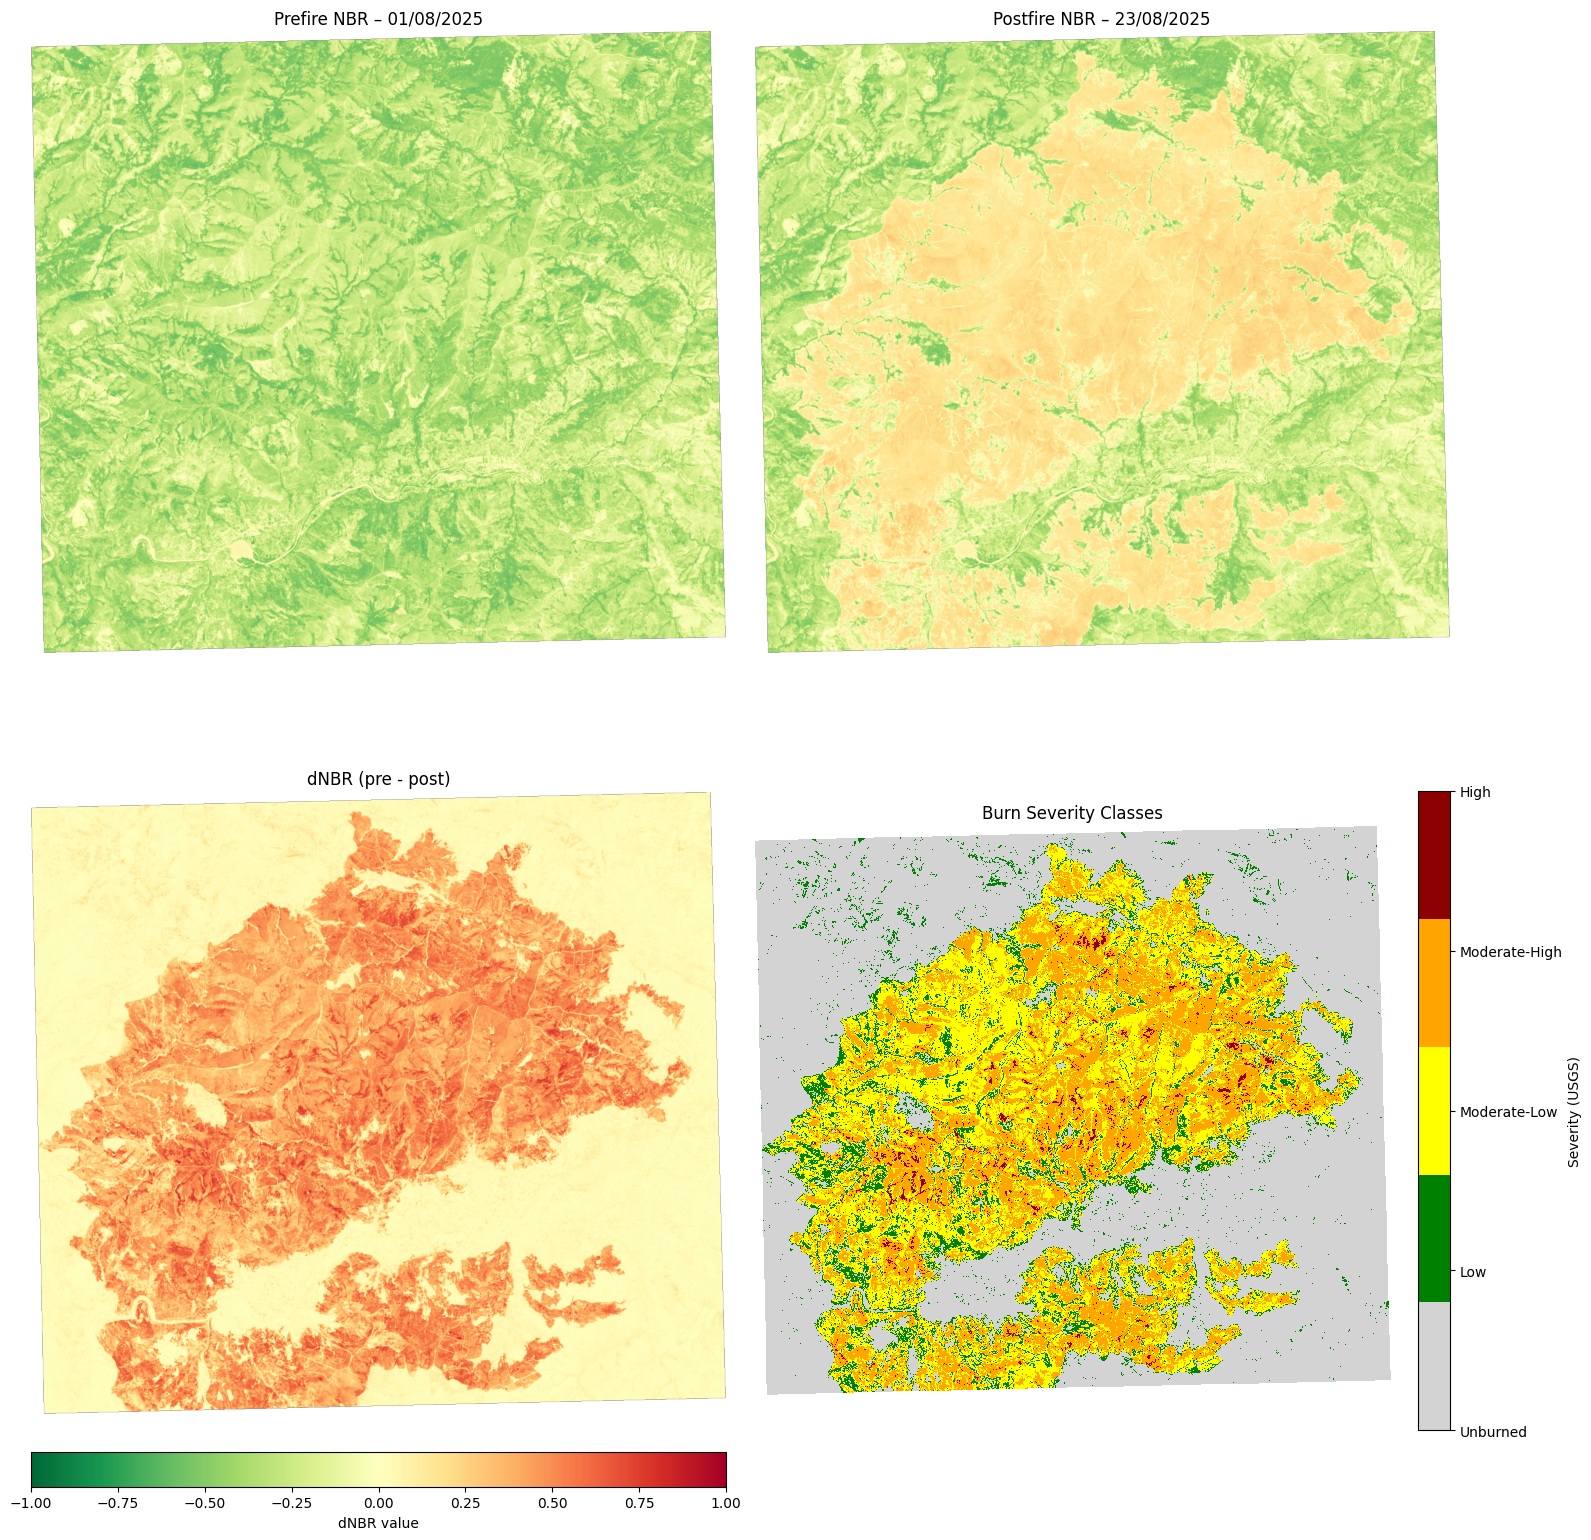

In [9]:
nodata = -9999.0

#5. Create masked arrays for plotting
nbr_pre_masked = ma.masked_equal(nbr_pre, nodata).squeeze()
nbr_post_masked = ma.masked_equal(nbr_post, nodata).squeeze()
dnbr_masked = ma.masked_equal(dnbr, nodata).squeeze()
severity_masked = ma.masked_equal(severity, 255).squeeze()

# 6. Define colormap
severity_cmap = ListedColormap(['lightgray', 'green', 'yellow', 'orange', 'darkred'])
severity_labels = ['Unburned', 'Low', 'Moderate-Low', 'Moderate-High', 'High']

# 7. Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Prefire NBR
axes[0,0].imshow(nbr_pre_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,0].set_title("Prefire NBR – 01/08/2025")
axes[0,0].axis('off')

# Postfire NBR
axes[0,1].imshow(nbr_post_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,1].set_title("Postfire NBR – 23/08/2025")
axes[0,1].axis('off')

# dNBR
im_dnbr = axes[1,0].imshow(dnbr_masked, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[1,0].set_title("dNBR (pre - post)")
axes[1,0].axis('off')

# Severity classes
im_sev = axes[1,1].imshow(severity_masked, cmap=severity_cmap, vmin=0, vmax=4, interpolation='nearest')
axes[1,1].set_title("Burn Severity Classes")
axes[1,1].axis('off')

# Colorbars
cbar_dnbr = fig.colorbar(im_dnbr, ax=axes[1,0], orientation='horizontal', fraction=0.05, pad=0.05)
cbar_dnbr.set_label('dNBR value')

cbar_sev = fig.colorbar(im_sev, ax=axes[1,1], ticks=range(5), fraction=0.046, pad=0.04)
cbar_sev.set_ticklabels(severity_labels)
cbar_sev.set_label('Severity (USGS)')

plt.tight_layout()
plt.show()

## 5. Extract Burn Scar Polygons

- Threshold filtering
- Morphological operations
- Vectorization

In [10]:
def create_burn_scar_polygon(dnbr_path, threshold, min_area_ha, output_path=None):
    """
    Convert dNBR raster to binary burn scar polygon
    
    Parameters:
        dnbr_path: Path to dNBR raster
        threshold: dNBR threshold for burned (default 0.1 = USGS "low severity" minimun)
        min_area_ha: Minimum patch size to keep (removes noise)
        output_path: Where to save the polygon (optional)
    
    Returns:
        Geodataframe with burn scar polygon(s)
    """

    #1. Load dNBR
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = 255

    
    #2. Create binary burn mask (burned = 1, unburned = 0)
    burn_mask = np.zeros_like(dnbr, dtype='uint8')

    # Only classify valid pixels (not nodata)
    valid_mask = (dnbr != nodata)
    burn_mask[valid_mask & (dnbr >= threshold)] = 1

    burned_pixels = np.sum(burn_mask == 1)
    total_valid = np.sum(valid_mask)

    print(f"\nThreshold: dNBR >= {threshold}")
    print(f" Burned pixels: {burned_pixels:,} ({burned_pixels / total_valid*100:.2f}% of valid area)")

    #Fill small holes inside burned areas
    burn_mask_filled = binary_fill_holes(burn_mask)

    #Close small gaps (connects nearby burned pixels)
    #Adjust iterations based on your pixel size (higher = more aggresive smoothing)
    structure = np.ones((3, 3)) #3x3 kernel
    burn_mask_closed = binary_closing(burn_mask_filled, structure=structure)

    #Convert back to uint8 for rasterio.features.shapes()
    burn_mask_closed = burn_mask_closed.astype('uint8')

    burn_pixels_after = np.sum(burn_mask_closed == 1)
    print(f"Burned pixels (after morphology): {burn_pixels_after:,} ({burn_pixels_after / total_valid*100:.2f}%)")
    
    #3. Convert to polygons

    records = []

    for geom, value in shapes(
        burn_mask_closed,
        mask=(burn_mask_closed == 1), #Only extract burned pixels
        transform=transform
    ):
        records.append({
            'geometry': shape(geom),
            'burned': int(value)
        })

    if not records:
        print("Error: No burned areas detected above threshold")
        return None
    
    gdf = gpd.GeoDataFrame(records, crs=crs)

    #4. Calculate areas and filter small patches
    pixel_area_m2 = abs(transform[0]*transform[4])
    gdf['area_m2'] = gdf.geometry.area
    gdf['area_ha'] = gdf['area_m2'] / 10_000

    print(f"\nInitial polygons: {len(gdf)}")
    print(f" Total area: {gdf['area_ha'].sum():.2f} ha")

    #Filter small patches (noice)
    gdf_filtered = gdf[gdf['area_ha'] >= min_area_ha].copy()

    removed = len(gdf) - len(gdf_filtered)
    if removed > 0:
        print(f"Removed {removed} small patches (< {min_area_ha} ha)")

    #5. Merge all geometries
    merged_geom = unary_union(gdf_filtered.geometry)

    #Create final GeoDataFrame

    gdf_dissolved = gpd.GeoDataFrame(
        {
            'burned': [1],
            'area_m2': [merged_geom.area],
            'area_ha': [merged_geom.area / 10_000],
            'area_km2': [merged_geom.area / 1_000_000],
            'perimeter_m': [merged_geom.length],
            'perimeter_km': [merged_geom.length / 1000],
            'n_patches': [len(gdf_filtered)],
            'dnbr_threshold': [threshold]
        },
        geometry=[merged_geom],
        crs=crs
    )

    print(f"\nFinal burn scar:")
    print(f" Area: {gdf_dissolved['area_ha'].iloc[0]:.2f} ha ({gdf_dissolved['area_km2'].iloc[0]:.2f} km2)")
    print(f" Number of patches: {gdf_dissolved['n_patches'].iloc[0]}")

    #Save as geopackage
    if output_path:
        gdf_dissolved.to_file(output_path, driver="GPKG")
        print(f"\n Burn scar polygons saved to: {output_path}")

    return gdf_dissolved

In [25]:
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.1,
    min_area_ha=15.0,
    output_path=POLYGON_PATH
)


Threshold: dNBR >= 0.1
 Burned pixels: 906,864 (48.93% of valid area)
Burned pixels (after morphology): 949,928 (51.25%)

Initial polygons: 2782
 Total area: 37997.12 ha
Removed 2778 small patches (< 15.0 ha)

Final burn scar:
 Area: 37285.12 ha (372.85 km2)
 Number of patches: 4

 Burn scar polygons saved to: c:\Repos\ARua_Wildfire\output\non_qa\burn_polygons_no_qa.gpkg


## 5. Validation & Statistics

- Compare with reference data
- Calculate area by severity
- Cross-tabulate with land cover

In [26]:
def compare_burn_scars(predicted_polygon_path, reference_polygon_path, output_dir):
    """
    Compare predicted burn scar with reference (Copernicus EMS observed event)

    Parameters:
        predicted_polygon_path: dNBR-derived burn scar
        reference_polygon_path: Copernicus EMS
        output_dir: Where to save comparison outputs

    Returns:
        Dictionary with comparison metrics
    """

    #1. Load polygons
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    reference_gdf = gpd.read_file(reference_polygon_path)

    print(f"\nPredicted: {len(predicted_gdf)} features")
    print(f"Reference: {len(reference_gdf)} features")

    #2. Reprojected if needed
    if predicted_gdf.crs != reference_gdf.crs:
        print(f" \nReprojecting reference from {reference_gdf.crs} to {predicted_gdf.crs}")

    #3. Dissolve to single geometry
    predicted_geom = unary_union(predicted_gdf.geometry)
    reference_geom = unary_union(reference_gdf.geometry)

    #4.Calculate basic metrics
    pred_area = predicted_geom.area
    ref_area = reference_geom.area
    pred_perimeter = predicted_geom.length
    ref_perimeter = reference_geom.length

    print("Area Comparison")
    print(f"Reference area: {ref_area/10_000:>10,.2f} ha ({ref_area/1_000_000:>8,.2f} km2)")
    print(f"Predicted area: {pred_area/10_000:>10,.2f} ha ({pred_area/1_000_000:>8,.2f}) km2")
    area_diff = pred_area - ref_area
    area_diff_pct = (area_diff / ref_area) * 100

    print(f"Difference: {area_diff/10_000:>+10,.2f} ha ({area_diff_pct:>+8,.2f}%)")

    print("Perimeter Comparison")
    print(f"Reference perimeter: {ref_perimeter/1000:>10,.2f} km")
    print(f"Predicted perimeter: {pred_perimeter/1000:>10,.2f} km")

    perim_diff = pred_perimeter - ref_perimeter
    perim_diff_pct = (perim_diff / ref_perimeter) * 100

    print(f"Difference: {perim_diff/1000:>+10,.2f} km ({perim_diff_pct:>+8,.2f})")

    #5. Spatial overlap metrics

    print("Spatial overlap metrics")
    #Intersection (area correctly identified as burned)
    intersection = predicted_geom.intersection(reference_geom)
    intersection_area = intersection.area

    #Union (total burned area in either dataset)
    union = predicted_geom.union(reference_geom)
    union_area = union.area

    #Difference (errors)
    false_positive = predicted_geom.difference(reference_geom)
    false_negative = reference_geom.difference(predicted_geom)

    fp_area = false_positive.area
    fn_area = false_negative.area

    #Calculate accuracy metrics
    iou = intersection_area / union_area # Jaccard Index / Intersection over Union
    dice = (2 * intersection_area) / (pred_area + ref_area) # Dice / F1
    precision = intersection_area / pred_area if pred_area > 0 else 0
    recall = intersection_area / ref_area if ref_area > 0 else 0

    print(f"Intersection (correct): {intersection_area/10_000:>10,.2f} ha")
    print(f"Union (total):          {union_area/10_000:>10,.2f} ha")
    print(f"False Positive (over):  {fp_area/10_000:>10,.2f} ha ({fp_area/ref_area*100:>6,.2f}% of ref)")
    print(f"False Negative (under): {fn_area/10_000:>10,.2f} ha ({fn_area/ref_area*100:>6,.2f}% of ref)")
    print()
    print(f"IoU (Jaccard Index):    {iou:>10.4f} ({iou*100:>6.2f}%)")
    print(f"Dice Coefficient (F1):  {dice:>10.4f} ({dice*100:>6.2f}%)")
    print(f"Precision:              {precision:>10.4f} ({precision*100:>6.2f}%)")
    print(f"Recall:                 {recall:>10.4f} ({recall*100:6.2f}%)")


    #6. Shape metrics (compactness)

    #Compactness = area / perimeter^2 (normalized, 1.0 = perfect circle)
    print("Shape metrics")
    pred_compact = (4 * np.pi * pred_area) / (pred_perimeter ** 2)
    ref_compact = (4 * np.pi * ref_area) / (ref_perimeter ** 2)

    print(f"Reference compactness:  {ref_compact:.4f}")
    print(f"Predicted compactness:  {pred_compact:.4f}")
    print(f"(1.0 = perfect circle, lower = more irregular/fragmented)")

    #7. Save outputs if requested
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

        #Save difference geometries
        error_gdf = gpd.GeoDataFrame(
            {
                'error_type': ['False Positive (over-mapped)', 'False Negative (under-mapped)'],
                'area_ha': [fp_area/10_000, fn_area/10_000],
                'area_pct': [fp_area/ref_area*100, fn_area/ref_area*100]
            },
            geometry=[false_positive, false_negative],
            crs=predicted_gdf.crs
        )

        error_path = os.path.join(output_dir, "burn_scar_errors.gpkg")
        error_gdf.to_file(error_path, driver='GPKG')
        print(f"\nSaved error polygons to: {error_path}")

        #Save metrics to CSV

        metrics = {
            'Metric': [
                'Reference Area (ha)', 'Predicted Area (ha)', 'Area Difference (ha)', 'Area Difference (%)',
                'Reference Perimeter (km)', 'Predicted Perimeter (km)', 'Perimeter Difference (%)', 'Perimeter_Difference (%)',
                'Intersection (ha)', 'Union (ha)', 'False Positive (ha)', 'False_Negative (ha)',
                'IoU', 'Dice/F1', 'Precision', 'Recall',
                'Reference Compactness', 'Predicted Compacteness'
            ],
            'Value': [
                ref_area/10_000, pred_area/10_000, area_diff/10_000, area_diff_pct,
                ref_perimeter/1000, pred_perimeter/1000, perim_diff/1000, perim_diff_pct,
                intersection_area/10_000, union_area/10_000, fp_area/10_000, fn_area/10_000,
                iou, dice, precision, recall,
                ref_compact, pred_compact
            ]
        }

        metrics_df = pd.DataFrame(metrics)
        metrics_path = os.path.join(output_dir, 'comparison_metrics.csv')
        metrics_df.to_csv(metrics_path, index=False)
        print(f"Saved metrics to: {metrics_path}")

        #8. Return results

        results = {
            'predicted_geom': predicted_geom,
            'reference_geom': reference_geom,
            'intersection': intersection,
            'false_positive': false_positive,
            'false_negative': false_negative,
            'metrics': {
                'area_pred_ha': pred_area/10_000,
                'area_ref_ha': ref_area/10_000,
                'area_diff_pct': area_diff_pct,
                'perimeter_pred_km': pred_perimeter/1000,
                'perimeter_ref_km': ref_perimeter/10_000,
                'perimeter_diff_pct': perim_diff_pct,
                'iou': iou,
                'dice': dice,
                'precision': precision,
                'recall': recall,
                'false_positive_ha': fp_area/10_000,
                'false_negative_ha': fn_area/10_000
            }
        }
        
        return results

In [27]:
compare = compare_burn_scars(
    POLYGON_PATH,
    FIRE_PATH,
    OUTPUT_DIR
)


Predicted: 1 features
Reference: 454 features
Area Comparison
Reference area:  33,002.94 ha (  330.03 km2)
Predicted area:  37,285.12 ha (  372.85) km2
Difference:  +4,282.18 ha (  +12.98%)
Perimeter Comparison
Reference perimeter:   2,814.11 km
Predicted perimeter:     391.44 km
Difference:  -2,422.67 km (  -86.09)
Spatial overlap metrics
Intersection (correct):  32,950.66 ha
Union (total):           37,337.40 ha
False Positive (over):    4,334.46 ha ( 13.13% of ref)
False Negative (under):      52.28 ha (  0.16% of ref)

IoU (Jaccard Index):        0.8825 ( 88.25%)
Dice Coefficient (F1):      0.9376 ( 93.76%)
Precision:                  0.8837 ( 88.37%)
Recall:                     0.9984 ( 99.84%)
Shape metrics
Reference compactness:  0.0005
Predicted compactness:  0.0306
(1.0 = perfect circle, lower = more irregular/fragmented)

Saved error polygons to: c:\Repos\ARua_Wildfire\output\non_qa\burn_scar_errors.gpkg
Saved metrics to: c:\Repos\ARua_Wildfire\output\non_qa\comparison_metri

In [21]:
def severity_area(predicted_polygon_path, severity_path, output_dir, severity_labels=None):

    if severity_labels is None:
    # Define labels **inside** the function (or pass as argument / import from config)
        severity_labels = {
            0: "Unburned",
            1: "Low",
            2: "Moderate-Low",
            3: "Moderate-High",
            4: "High"
        }
    
# 1. Load predicted burn polygons and merge them
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    # Optional: check/fix CRS match
    if predicted_gdf.crs != "EPSG:32629":
        predicted_gdf = predicted_gdf.to_crs("EPSG:32629")
    
    predicted_geom = unary_union(predicted_gdf.geometry)
    # Make sure it's a list of geometries for rasterio.mask
    shapes_geom = [predicted_geom.__geo_interface__] if predicted_geom.geom_type != "GeometryCollection" else \
                  [g.__geo_interface__ for g in predicted_geom.geoms]

# 2. Load severity raster and extract only inside predicted area
    with rasterio.open(severity_path) as src:
        severity_meta = src.meta.copy()
        severity_data, transform = mask(
            src,
            shapes_geom,
            crop=True,
            nodata=255,           # use a value outside 0–4
            filled=False          # keep as masked array
        )
        severity = severity_data[0]  # single band
        severity_meta.update({
            "driver": "GTiff",
            "height": severity.shape[0],
            "width": severity.shape[1],
            "transform": transform
        })

# 3. Remove masked pixels:
    severity_flat = severity[~severity.mask]  # remove masked pixels
    if severity_flat.size == 0:
        print("No valid pixels inside predicted area.")
        return None, None

    # Count pixels per class
    unique, counts = np.unique(severity_flat, return_counts=True)

    # Pixel area in hectares
    pixel_area_ha = abs(severity_meta["transform"].a * severity_meta["transform"].e) / 10_000

    # Build table
    area_table = []
    for val, cnt in zip(unique, counts):
        if val not in severity_labels:  # skip unexpected values
            continue
        area_ha = cnt * pixel_area_ha
        area_table.append({
            "severity": int(val),
            "severity_label": severity_labels.get(int(val), "Other"),
            "area_ha": area_ha
        })

    area_table = gpd.GeoDataFrame(area_table).sort_values("severity")

    area_table_path = os.path.join(output_dir, 'severity_aoi_non_qa.csv')
    area_table.to_csv(area_table_path, index=False)
    print(f"Burned severity area saved to: {area_table_path}")
    
    print(area_table)

In [22]:
burn_severity_area = severity_area(
    POLYGON_PATH,
    SEVERITY_PATH,
    OUTPUT_DIR
)

Burned severity area saved to: c:\Repos\ARua_Wildfire\output\non_qa\severity_aoi_non_qa.csv
   severity severity_label   area_ha
0         0       Unburned   1616.16
1         1            Low   5100.96
2         2   Moderate-Low  15269.72
3         3  Moderate-High  14630.44
4         4           High    728.16


In [23]:
def severity_landcover_stats(
        predicted_polygon_path, 
        severity_path, 
        landcover_path, 
        output_dir,
        severity_labels=None,
        landcover_class_col: str = "info"):
    
    if severity_labels is None:
        severity_labels = {
            0: "Unburned", 1: "Low", 2: "Moderate-Low",
            3: "Moderate-High", 4: "High"
        }
    
    # 1. Load predicted burn area (merge to one geometry)
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    if predicted_gdf.crs != "EPSG:32629":
        predicted_gdf = predicted_gdf.to_crs("EPSG:32629")
    predicted_geom = unary_union(predicted_gdf.geometry)
    burn_shapes = [predicted_geom.__geo_interface__]
    
    # 2. Load & mask severity raster to burn area
    with rasterio.open(severity_path) as src_sev:
        sev_meta = src_sev.meta.copy()
        sev_data, sev_transform = mask(
            src_sev, burn_shapes, crop=True, nodata=255, filled=True 
        )
        sev = sev_data[0]  # shape (height, width)
        sev_meta.update({
            "height": sev.shape[0],
            "width": sev.shape[1],
            "transform": sev_transform
        })
    
    # 3. Load land cover GeoJSON and clip to burn area
    lc_gdf = gpd.read_file(landcover_path)
    if lc_gdf.crs != "EPSG:32629":
        lc_gdf = lc_gdf.to_crs("EPSG:32629")
    lc_gdf = lc_gdf[lc_gdf.intersects(predicted_geom)].copy()
    
    if lc_gdf.empty:
        print("No land cover polygons intersect the predicted burn area")
        return None, None, None
    
    # 4. Create numeric mapping for land cover classes
    unique_classes = lc_gdf[landcover_class_col].unique()
    class_to_code = {cls: idx for idx, cls in enumerate(unique_classes, start=1)}
    code_to_class = {idx: cls for cls, idx in class_to_code.items()}
    
    # Add numeric codes to GeoDataFrame
    lc_gdf['lc_code'] = lc_gdf[landcover_class_col].map(class_to_code)
    
    # 5. Rasterize land cover to match severity grid
    lc_shapes = ((geom, code) for geom, code in zip(
        lc_gdf.geometry, lc_gdf['lc_code']
    ))
    
    lc_raster = rasterize(
        lc_shapes,
        out_shape=sev.shape,
        transform=sev_transform,
        fill=255,
        dtype=np.uint16,
        all_touched=False
    )
    
    # 6. Valid pixels: both severity and land cover are valid
    valid_mask = (sev != 255) & (lc_raster != 255)
    sev_valid = sev[valid_mask]
    lc_valid = lc_raster[valid_mask]
    
    if sev_valid.size == 0:
        print("No overlapping valid pixels between severity and land cover.")
        return None, None, None
    
    # 7. Pixel area in ha
    pixel_area_ha = abs(sev_transform.a * sev_transform.e) / 10_000
    
    # 8. Count per severity x landcover combination
    multiplier = 10000
    combined = sev_valid.astype(np.int64) * multiplier + lc_valid.astype(np.int64)
    unique_comb, counts = np.unique(combined, return_counts=True)
    
    # 9. Build detailed table
    results = []
    for comb, cnt in zip(unique_comb, counts):
        sev_code = int(comb // multiplier)
        lc_code = int(comb % multiplier)
        area_ha = cnt * pixel_area_ha
        results.append({
            "severity": sev_code,
            "severity_label": severity_labels.get(sev_code, f"Unknown ({sev_code})"),
            "landcover_code": lc_code,
            "landcover_label": code_to_class.get(lc_code, f"Unknown ({lc_code})"),
            "pixels": int(cnt),
            "area_ha": round(area_ha, 3)
        })
    
    df_detailed = pd.DataFrame(results)
    
    # 10. Create summary by severity
    df_summary = df_detailed.groupby(['severity', 'severity_label']).agg({
        'pixels': 'sum',
        'area_ha': 'sum'
    }).reset_index()

    #11. Top-3 land cover by severity
    top3 = (df_detailed
    .sort_values(['severity_label', 'area_ha'], ascending=[True, False])
    .groupby('severity_label', as_index=False)
    .head(3)
    )
    
    print("\n=== Summary by Severity ===")
    print(df_summary.to_string(index=False))
    print("\n=== Top-3 land cover types by Severity ===")
    print(top3.to_string(index=False))

    df_summary_path = os.path.join(output_dir, 'severity_burned_non_qa.csv')
    df_summary.to_csv(df_summary_path, index=False)
    print(f"Burned area by severity class saved to: {df_summary_path}")

    top3_path = os.path.join(output_dir, 'top3_landcover_non_qa.csv')
    top3.to_csv(top3_path, index=False)
    print(f"Top-3 landcover by severity class saved to: {top3_path}")
    
    return df_detailed, df_summary, top3

In [24]:
top_3 = severity_landcover_stats(
    POLYGON_PATH,
    SEVERITY_PATH,
    LANDUSE_PATH,
    OUTPUT_DIR
)


=== Summary by Severity ===
 severity severity_label  pixels  area_ha
        0       Unburned    4967   198.68
        1            Low   71752  2870.08
        2   Moderate-Low  364770 14590.80
        3  Moderate-High  363815 14552.60
        4           High   18187   727.48

=== Top-3 land cover types by Severity ===
 severity severity_label  landcover_code                                                                            landcover_label  pixels  area_ha
        4           High               2                                                                    322-Moors and heathland    7358   294.32
        4           High               8                                                                    311-Broad-leaved forest    4513   180.52
        4           High               4                                                            324-Transitional woodland shrub    3353   134.12
        1            Low               2                                       